# Requirements

In [ ]:
!pip install demoji
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git
!pip install Levenshtein
!pip install gensim
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 1.5 MB/s eta 0:00:00
  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-6iwkrwgi
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-6iwkrwgi
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
  Created wheel for mpstemmer: filename=mpstemmer-0.1.0-py3-none-any.whl size=99832 sha256=04ac71cc8452ffed8e5d2892ed2f88f1d0f2e0cbaff330396421ddc6d3a422ac
  Stored in directory: /tmp/pip-ephem-wheel-cache-v6lmhs_2/wheels/d0/b9/fd/dba0c7d44e5338db51da6ffcbe96db4326db3996a403f5ced1
Successfully built mpstemmer
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 57.2 MB/s eta 0:00:00


In [ ]:
import requests
import json
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import demoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from mpstemmer import MPStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk import word_tokenize
from tqdm import tqdm
from umap import UMAP
import plotly.express as px
import gensim.models
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#Scraping

In [ ]:
all_data = []

for page in range(1, 11):
    resp = requests.get(f'https://api.openbrewerydb.org/v1/breweries?by_country=Australia&page={page}&per_page=20')
    data = resp.json()
    if not data:
        break
    all_data.extend(data)

# Preprocessing Text

Remove Punctuation

In [ ]:
text = ' '.join([x['name'] for x in all_data])
def remove_punc(text):
    text = re.sub(r'[^\w\s]', '', text)
    return text

hasil_rp = remove_punc(text)
hasil_rp

'2 HALFS Brewing Distilling 27 South Brewing 3 Ravens 3806 Brewing 4 Pines 7th Day Brewery Aether Brewing Akasha Brewing Company Ale Mary Brewing Co Alefarm Brewing Alice Springs Brewing Co All Inn Brewing Co Australian Beer Company Bacchus Brewing Co Bad Shepherd Brewing Co Bad Shepherd Brewing Co Badlands Brewery Bailey Brewing Co Ballistic Beer Co Ballistic Beer Co Balter Brewing Balter Brewing Company Barossa Valley Brewing Basement Brewhouse Batch Brewing Co Batch Brewing Co Batch Brewing Company Bay Road Brewing Beaver Brewery Beer Fontaine Beer Garden Brewing Beerfarm Bells Beach Brewing Bendigo Brewing Benson Brothers Brewing Bent Bridge Brewing Bentspoke Brewing Co BentSpoke Brewing Co Bicheno Beer Co Bicheno Brewing Big Little Brewing Big Niles Brewing Co Big Shed Brewing Co Big Shed Brewing Concern Billycart Brewing Bilpin Cider Black Brewing Co Black Dog Brewing Co Black Hops Black Hops Brewing Blackflag Brewing Blackmans Brewery Blackmans Brewery Blackwattle Brewery Blasta

Lowercasing

In [ ]:
hasil_lower = hasil_rp.lower()
hasil_lower

'2 halfs brewing distilling 27 south brewing 3 ravens 3806 brewing 4 pines 7th day brewery aether brewing akasha brewing company ale mary brewing co alefarm brewing alice springs brewing co all inn brewing co australian beer company bacchus brewing co bad shepherd brewing co bad shepherd brewing co badlands brewery bailey brewing co ballistic beer co ballistic beer co balter brewing balter brewing company barossa valley brewing basement brewhouse batch brewing co batch brewing co batch brewing company bay road brewing beaver brewery beer fontaine beer garden brewing beerfarm bells beach brewing bendigo brewing benson brothers brewing bent bridge brewing bentspoke brewing co bentspoke brewing co bicheno beer co bicheno brewing big little brewing big niles brewing co big shed brewing co big shed brewing concern billycart brewing bilpin cider black brewing co black dog brewing co black hops black hops brewing blackflag brewing blackmans brewery blackmans brewery blackwattle brewery blasta

Remove URL

In [ ]:
text = ' '.join([f"{x['name']} {str(x['website_url'])}" for x in all_data])
def remove_rls(text):
    text = re.sub(r'https?\/\/S+', '',  str(text)) # remove the hyperlink
    text = re.sub(r'http\S+', '',  str(text)) # remove the hyperlink
    text = re.sub(r'www\S+', '',  str(text)) # remove the www
    text = re.sub(r'\S+@\S+', '', str(text)) # remove the email
    return text

hasil = "".join(text)
hasil_rl = remove_rls(hasil)
print(hasil_rl)

2 HALFS Brewing Distilling  27 South Brewing  3 Ravens  3806 Brewing  4 Pines None 7th Day Brewery  Aether Brewing  Akasha Brewing Company  Ale Mary Brewing Co.  Alefarm Brewing  Alice Springs Brewing Co.  All Inn Brewing Co.  Australian Beer Company  Bacchus Brewing Co  Bad Shepherd Brewing Co  Bad Shepherd Brewing Co.  Badlands Brewery  Bailey Brewing Co.  Ballistic Beer Co  Ballistic Beer Co.  Balter Brewing  Balter Brewing Company  Barossa Valley Brewing  Basement Brewhouse  Batch Brewing Co  Batch Brewing Co.  Batch Brewing Company  Bay Road Brewing  Beaver Brewery  Beer Fontaine  Beer Garden Brewing  Beerfarm  Bells Beach Brewing  Bendigo Brewing  Benson Brothers Brewing  Bent Bridge Brewing  Bentspoke Brewing Co  BentSpoke Brewing Co.  Bicheno Beer Co.  Bicheno Brewing  Big Little Brewing  Big Niles Brewing Co.  Big Shed Brewing Co  Big Shed Brewing Concern  Billycart Brewing  Bilpin Cider  Black Brewing Co  Black Dog Brewing Co  Black Hops  Black Hops Brewing  Blackflag Brewing

Remove emojis

In [ ]:
def remove_emoji(text):
    cleaned_text = demoji.replace(text,repl="")
    return cleaned_text
hasil_re = remove_emoji(hasil_lower)
hasil_re

'2 halfs brewing distilling 27 south brewing 3 ravens 3806 brewing 4 pines 7th day brewery aether brewing akasha brewing company ale mary brewing co alefarm brewing alice springs brewing co all inn brewing co australian beer company bacchus brewing co bad shepherd brewing co bad shepherd brewing co badlands brewery bailey brewing co ballistic beer co ballistic beer co balter brewing balter brewing company barossa valley brewing basement brewhouse batch brewing co batch brewing co batch brewing company bay road brewing beaver brewery beer fontaine beer garden brewing beerfarm bells beach brewing bendigo brewing benson brothers brewing bent bridge brewing bentspoke brewing co bentspoke brewing co bicheno beer co bicheno brewing big little brewing big niles brewing co big shed brewing co big shed brewing concern billycart brewing bilpin cider black brewing co black dog brewing co black hops black hops brewing blackflag brewing blackmans brewery blackmans brewery blackwattle brewery blasta

WordCloud All

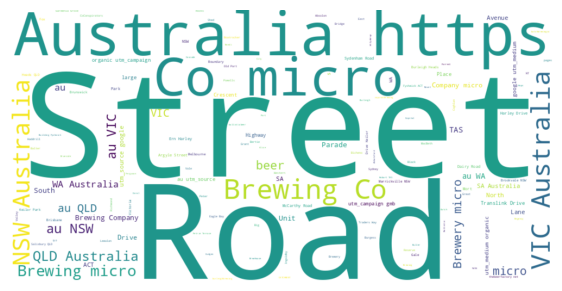

In [ ]:
text = ' '.join(
    str(val)
    for item in all_data
    for val in item.values()
    if val is not None
)

wordcloud = WordCloud(width=1000, height=500, background_color='white', max_words=500).generate(text)

plt.figure(figsize=(7, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Stopwords

In [ ]:
import nltk
from nltk.corpus import stopwords

print(stopwords.words('english'))
print(stopwords.words('indonesian'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
sw = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join(w for w in str(text).split() if w.lower() not in sw)

hasil_st = remove_stopwords(hasil_re)
print(hasil_st)

2 halfs brewing distilling 27 south brewing 3 ravens 3806 brewing 4 pines 7th day brewery aether brewing akasha brewing company ale mary brewing co alefarm brewing alice springs brewing co inn brewing co australian beer company bacchus brewing co bad shepherd brewing co bad shepherd brewing co badlands brewery bailey brewing co ballistic beer co ballistic beer co balter brewing balter brewing company barossa valley brewing basement brewhouse batch brewing co batch brewing co batch brewing company bay road brewing beaver brewery beer fontaine beer garden brewing beerfarm bells beach brewing bendigo brewing benson brothers brewing bent bridge brewing bentspoke brewing co bentspoke brewing co bicheno beer co bicheno brewing big little brewing big niles brewing co big shed brewing co big shed brewing concern billycart brewing bilpin cider black brewing co black dog brewing co black hops black hops brewing blackflag brewing blackmans brewery blackmans brewery blackwattle brewery blasta brew

Stemming

In [ ]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def process_text(text):
    tokens = nltk.word_tokenize(text.lower())
    return ' '.join([stemmer.stem(w) for w in tokens])
hasil_stemming = process_text(hasil_st)
print(hasil_stemming)

2 half brew distil 27 south brew 3 raven 3806 brew 4 pine 7th day breweri aether brew akasha brew compani ale mari brew co alefarm brew alic spring brew co inn brew co australian beer compani bacchu brew co bad shepherd brew co bad shepherd brew co badland breweri bailey brew co ballist beer co ballist beer co balter brew balter brew compani barossa valley brew basement brewhous batch brew co batch brew co batch brew compani bay road brew beaver breweri beer fontain beer garden brew beerfarm bell beach brew bendigo brew benson brother brew bent bridg brew bentspok brew co bentspok brew co bicheno beer co bicheno brew big littl brew big nile brew co big shed brew co big shed brew concern billycart brew bilpin cider black brew co black dog brew co black hop black hop brew blackflag brew blackman breweri blackman breweri blackwattl breweri blasta brew co blind boy brew block n tackl breweri boatrock brewer distil boatrock brew co bodriggi brew co boil pot brew co bondi brew co bone idol b

# Feature Engineering

One Hot Encoding

In [ ]:
vectorizer = CountVectorizer()
documents = hasil_stemming.split()
X = vectorizer.fit_transform(documents)
df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df

,27,3806,7th,abbott,aether,akasha,ale,alefarm,alic,australia,...,son,south,spring,street,tackl,time,tree,unit,valley,way
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
568,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
569,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
570,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


TF-IDF

In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(documents)
df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df

,27,3806,7th,abbott,aether,akasha,ale,alefarm,alic,australia,...,son,south,spring,street,tackl,time,tree,unit,valley,way
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Tokenize Sentence

In [ ]:
sentences = [word_tokenize(doc) for doc in tqdm(documents)]
sentences

100%|██████████| 572/572 [00:00<00:00, 28425.51it/s]


[['2'],
 ['half'],
 ['brew'],
 ['distil'],
 ['27'],
 ['south'],
 ['brew'],
 ['3'],
 ['raven'],
 ['3806'],
 ['brew'],
 ['4'],
 ['pine'],
 ['7th'],
 ['day'],
 ['breweri'],
 ['aether'],
 ['brew'],
 ['akasha'],
 ['brew'],
 ['compani'],
 ['ale'],
 ['mari'],
 ['brew'],
 ['co'],
 ['alefarm'],
 ['brew'],
 ['alic'],
 ['spring'],
 ['brew'],
 ['co'],
 ['inn'],
 ['brew'],
 ['co'],
 ['australian'],
 ['beer'],
 ['compani'],
 ['bacchu'],
 ['brew'],
 ['co'],
 ['bad'],
 ['shepherd'],
 ['brew'],
 ['co'],
 ['bad'],
 ['shepherd'],
 ['brew'],
 ['co'],
 ['badland'],
 ['breweri'],
 ['bailey'],
 ['brew'],
 ['co'],
 ['ballist'],
 ['beer'],
 ['co'],
 ['ballist'],
 ['beer'],
 ['co'],
 ['balter'],
 ['brew'],
 ['balter'],
 ['brew'],
 ['compani'],
 ['barossa'],
 ['valley'],
 ['brew'],
 ['basement'],
 ['brewhous'],
 ['batch'],
 ['brew'],
 ['co'],
 ['batch'],
 ['brew'],
 ['co'],
 ['batch'],
 ['brew'],
 ['compani'],
 ['bay'],
 ['road'],
 ['brew'],
 ['beaver'],
 ['breweri'],
 ['beer'],
 ['fontain'],
 ['beer'],
 ['garde

Word2Vec Model

In [ ]:
model = gensim.models.Word2Vec(sentences, min_count=1, vector_size=100, window=5, sg=0)

In [ ]:
model.save('sentimen_tweet.w2v')

In [ ]:
model = gensim.models.Word2Vec.load('sentimen_tweet.w2v')

In [ ]:
w2v = model.wv
w2v.index_to_key[:10]

['brew',
 'co',
 'breweri',
 'compani',
 'beer',
 'road',
 'black',
 'big',
 'fox',
 'catchment']

In [ ]:
w2v.vectors.shape, w2v.vector_size

((252, 100), 100)

In [ ]:
w2v.similar_by_key('brew')

[('river', 0.2897421419620514),
 ('brix', 0.275379478931427),
 ('dog', 0.2731468081474304),
 ('firetail', 0.2295033037662506),
 ('brewpub', 0.22023281455039978),
 ('distil', 0.21883943676948547),
 ('catchment', 0.21617142856121063),
 ('brewski', 0.20657561719417572),
 ('goos', 0.20441339910030365),
 ('coconspir', 0.19543619453907013)]

In [ ]:
def get_document_vector(tokens, model):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not valid_vectors:
      return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)
X_features = np.array([get_document_vector(doc, model) for doc in sentences])
pd.DataFrame(X_features)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.004281,0.004983,0.004012,0.005305,0.006406,0.002250,0.007287,0.006847,0.004858,0.005346,...,0.003023,0.002770,0.002199,0.004682,0.008270,0.005971,-0.004245,-0.000547,-0.004951,0.003891
1,0.008891,0.003086,-0.000527,-0.004141,0.007183,-0.005909,0.008250,0.001039,-0.002483,0.008688,...,-0.000645,0.004750,-0.009567,-0.004921,-0.004957,0.008006,0.004100,-0.000857,-0.005945,0.009200
2,-0.000536,0.000236,0.005103,0.009009,-0.009303,-0.007117,0.006459,0.008973,-0.005015,-0.003763,...,0.001631,0.000190,0.003474,0.000218,0.009619,0.005061,-0.008917,-0.007042,0.000901,0.006393
3,0.001300,-0.009804,0.004588,-0.000538,0.006332,0.001783,-0.003130,0.007760,0.001555,0.000055,...,0.007012,0.004829,0.008683,0.007094,-0.005694,0.007241,-0.009295,-0.002588,-0.007757,0.004193
4,0.004776,0.001644,0.006559,-0.007340,-0.004175,-0.001067,0.000940,0.001466,-0.009673,-0.009598,...,-0.002553,-0.005323,-0.000513,-0.005397,-0.007829,0.008909,-0.008145,0.007190,0.002140,-0.004193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,-0.000536,0.000236,0.005103,0.009009,-0.009303,-0.007117,0.006459,0.008973,-0.005015,-0.003763,...,0.001631,0.000190,0.003474,0.000218,0.009619,0.005061,-0.008917,-0.007042,0.000901,0.006393
568,-0.006155,0.004668,-0.009071,0.005081,0.006352,0.006121,-0.007631,0.002833,-0.005453,0.009047,...,0.005861,0.000320,-0.005821,0.009000,-0.000653,0.004710,-0.001424,0.005798,0.005303,-0.007297
569,-0.000536,0.000236,0.005103,0.009009,-0.009303,-0.007117,0.006459,0.008973,-0.005015,-0.003763,...,0.001631,0.000190,0.003474,0.000218,0.009619,0.005061,-0.008917,-0.007042,0.000901,0.006393
570,-0.008620,0.003666,0.005190,0.005742,0.007467,-0.006168,0.001106,0.006047,-0.002840,-0.006174,...,0.001088,-0.001576,0.002197,-0.007882,-0.002717,0.002663,0.005347,-0.002392,-0.009510,0.004506


In [ ]:
X = UMAP().fit_transform(w2v.vectors)

df2 = pd.DataFrame(X, columns=['umap1', 'umap2'])
df2['word'] = w2v.index_to_key

fig = px.scatter(df2, x='umap1', y='umap2', text='word')
fig.update_traces(textposition='top center')
fig.update_layout(height = 800,
                  title_text = 'Word2Vec Visualization')
fig.show()

Build FastText Model

In [ ]:
model_fasttext = gensim.models.FastText(sentences, min_count=1,
                                        vector_size=100, window=5,
                                        min_n=3, max_n=6,
                                        sg=1, epochs=10)

In [ ]:
model_fasttext.save('sentimen_tweet.fasttext')

In [ ]:
model_fasttext = gensim.models.FastText.load('sentimen_tweet.fasttext')

In [ ]:
fastext = model_fasttext.wv
fastext.index_to_key[:50]

['brew',
 'co',
 'breweri',
 'compani',
 'beer',
 'road',
 'black',
 'big',
 'fox',
 'catchment',
 'capit',
 'burleigh',
 'hop',
 'bay',
 'batch',
 'ballist',
 'distil',
 'green',
 'great',
 'good',
 'gage',
 'futur',
 'hat',
 'feral',
 'endeavour',
 'craft',
 'deep',
 'common',
 'coconspir',
 'son',
 'creek',
 'island',
 'brewer',
 'boatrock',
 'blackman',
 'shed',
 'bicheno',
 'bentspok',
 'bridg',
 'brewhous',
 'valley',
 'balter',
 'shepherd',
 'bad',
 'south',
 'hawker',
 'hawk',
 'hard',
 'happi',
 'halfpac']

In [ ]:
fastext.vectors.shape

(252, 100)

In [ ]:
fastext.similar_by_key('brew')

[('brewer', 0.5082097053527832),
 ('brewdog', 0.4685882031917572),
 ('brewpub', 0.4322574734687805),
 ('brewman', 0.42524123191833496),
 ('breweri', 0.4113371670246124),
 ('brewski', 0.3214898705482483),
 ('brewhous', 0.319443941116333),
 ('brewcult', 0.2956864535808563),
 ('brevet', 0.2767646610736847),
 ('gage', 0.2617281973361969)]

In [ ]:
def get_document_vector(tokens, model):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not valid_vectors:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

X_features = np.array([get_document_vector(doc, model_fasttext) for doc in sentences])
pd.DataFrame(X_features)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.000564,0.001602,2.962554e-03,0.001391,-0.000502,0.000368,-0.001177,0.006763,-0.001676,0.005238,...,-0.002101,0.006106,0.004053,0.005860,0.001013,0.005921,-0.005581,0.004400,-0.003819,0.006275
1,-0.002654,0.000542,-1.238740e-04,-0.001342,-0.001731,-0.000216,0.000518,-0.000292,0.000992,0.000860,...,-0.000571,-0.000872,-0.000635,-0.000014,0.000863,-0.000480,0.001643,0.000163,0.001433,0.001879
2,0.000530,-0.002588,-2.445267e-03,0.002112,0.000045,-0.000900,0.000589,0.002376,0.000412,-0.002500,...,0.000177,0.003451,-0.001560,-0.002675,0.001460,0.002447,-0.001963,-0.001450,-0.001500,-0.000739
3,0.002026,0.000847,9.799719e-07,-0.000300,0.002606,0.001082,0.000265,0.000121,-0.000665,-0.000671,...,0.000383,-0.000578,0.001346,0.001386,0.000161,0.000632,0.000264,-0.001311,-0.000760,-0.000209
4,0.004317,-0.002003,3.020190e-04,-0.002893,-0.001381,0.001813,0.001900,0.002249,-0.001841,-0.001776,...,0.003297,-0.003939,0.003930,-0.004109,0.000050,0.000845,-0.002688,0.005871,-0.004045,-0.001758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,0.000530,-0.002588,-2.445267e-03,0.002112,0.000045,-0.000900,0.000589,0.002376,0.000412,-0.002500,...,0.000177,0.003451,-0.001560,-0.002675,0.001460,0.002447,-0.001963,-0.001450,-0.001500,-0.000739
568,-0.000165,-0.001303,-3.767289e-04,-0.000377,-0.000529,0.003129,0.001721,0.001498,-0.000587,-0.000502,...,0.000118,0.001949,0.000701,0.002026,-0.000098,0.002375,0.001093,0.001149,0.001488,0.001670
569,0.000530,-0.002588,-2.445267e-03,0.002112,0.000045,-0.000900,0.000589,0.002376,0.000412,-0.002500,...,0.000177,0.003451,-0.001560,-0.002675,0.001460,0.002447,-0.001963,-0.001450,-0.001500,-0.000739
570,-0.000212,0.002981,5.272667e-03,0.000512,-0.004625,-0.006693,0.002222,-0.003718,-0.000740,0.000227,...,0.000992,-0.001898,-0.003670,-0.001891,0.000917,0.003521,0.002951,0.000238,-0.002064,0.001923


In [ ]:
X = UMAP().fit_transform(fastext.vectors)

df2 = pd.DataFrame(X, columns=['umap1', 'umap2'])
df2['word'] = fastext.index_to_key

fig = px.scatter(df2, x='umap1', y='umap2', text='word')
fig.update_traces(textposition='top center')
fig.update_layout(height=800,
                  title_text='FastText Visualization')
fig.show()